<a href="https://colab.research.google.com/github/kshupe/wildlife-data-portfolio/blob/main/notebooks/dataprep_krugerelephants.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Elephant Movement Analysis: Kruger National Park
### Data Attribution & License
# **Study:** ThermochronTracking Elephants Kruger 2007
# **License:** CC BY-NC (Creative Commons Attribution-NonCommercial)
# **Principal Investigator:** Abi Tamim Vanak

# **Primary Citation:** > Slotow R, Thaker M, Vanak AT (2019) Data from: Fine-scale tracking of ambient temperature and movement reveals shuttling behavior of elephants to water. Movebank Data Repository. https://www.doi.org/10.5441/001/1.403h24q5

# **Associated Publication:** > Thaker M, Gupte PR, Prins HHT, Slotow R, Vanak AT. 2019. Fine-scale tracking of ambient temperature and movement reveals shuttling behavior of elephants to water. Front Ecol Evol. 7:4. https://doi.org/10.3389/fevo.2019.00004

# **Acknowledgements:** We thank SANParks for providing weather data and geographic shapefiles of Kruger NP, and the SANParks veterinary team for the collaring of elephants.

In [7]:
# Set up packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create a base path
BASE_PATH = "/content/drive/MyDrive/wildlife_data/projects/elephants_temperature_knp"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Create file path for data
DATA_PATH = f"{BASE_PATH}/data/raw/ThermochronTracking Elephants Kruger 2007.csv"
# Load the data
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(283688, 16)


,event-id,visible,timestamp,location-long,location-lat,external-temperature,sensor-type,individual-taxon-canonical-name,tag-local-identifier,individual-local-identifier,study-name,utm-easting,utm-northing,utm-zone,study-timezone,study-local-timestamp
0,9421351127,True,2007-08-13 00:30:00.000,31.87091,-24.81373,24.0,gps,Loxodonta africana,AM105,AM105,ThermochronTracking Elephants Kruger 2007,385887.864893,7.255206e+06,36S,GMT+02:00,2007-08-13 02:30:00.000
1,9421351128,True,2007-08-13 02:00:00.000,31.87399,-24.81483,23.0,gps,Loxodonta africana,AM105,AM105,ThermochronTracking Elephants Kruger 2007,386200.177878,7.255086e+06,36S,GMT+02:00,2007-08-13 04:00:00.000
2,9421351129,True,2007-08-13 03:31:00.000,31.87724,-24.81673,21.0,gps,Loxodonta africana,AM105,AM105,ThermochronTracking Elephants Kruger 2007,386530.396188,7.254879e+06,36S,GMT+02:00,2007-08-13 05:31:00.000
3,9421351130,True,2007-08-13 04:00:00.000,31.87822,-24.81569,21.0,gps,Loxodonta africana,AM105,AM105,ThermochronTracking Elephants Kruger 2007,386628.499769,7.254995e+06,36S,GMT+02:00,2007-08-13 06:00:00.000
4,9421351131,True,2007-08-13 06:00:00.000,31.89554,-24.79870,22.0,gps,Loxodonta africana,AM105,AM105,ThermochronTracking Elephants Kruger 2007,388363.850968,7.256890e+06,36S,GMT+02:00,2007-08-13 08:00:00.000


In [9]:
# temperature sanity check
df['external-temperature'].describe()

,external-temperature
count,283688.000000
mean,27.649129
std,6.369994
min,6.000000
25%,23.000000
50%,27.000000
75%,33.000000
max,47.000000


In [10]:
# how many individuals, how many fixes each
df['individual-local-identifier'].value_counts()

,count
individual-local-identifier,
AM91,31721
AM99,31449
AM110,26372
AM239,24299
AM254,24060
AM253,20455
AM93,19717
AM307,19641
AM255,18426


In [11]:
# clean and parse timestamps

df['timestamp'] = pd.to_datetime(df['timestamp'])

df_clean = df[(df['visible'] == True)].copy()

df_clean = df_clean.sort_values(['individual-local-identifier', 'timestamp']).reset_index(drop=True)

df_clean[['individual-local-identifier', 'timestamp',
          'location-lat', 'location-long',
          'external-temperature']].head()

,individual-local-identifier,timestamp,location-lat,location-long,external-temperature
0,AM105,2007-08-13 00:30:00,-24.81373,31.87091,24.0
1,AM105,2007-08-13 02:00:00,-24.81483,31.87399,23.0
2,AM105,2007-08-13 03:31:00,-24.81673,31.87724,21.0
3,AM105,2007-08-13 04:00:00,-24.81569,31.87822,21.0
4,AM105,2007-08-13 06:00:00,-24.79870,31.89554,22.0


In [12]:
# basic movement metrics (step length, speeed, turning angle)

from math import radians, degrees, sin, cos, atan2, sqrt

def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    return 2*R*atan2(sqrt(a), sqrt(1-a))

def bearing_deg(lat1, lon1, lat2, lon2):
    phi1, phi2 = radians(lat1), radians(lat2)
    dlambda = radians(lon2 - lon1)
    x = sin(dlambda) * cos(phi2)
    y = cos(phi1)*sin(phi2) - sin(phi1)*cos(phi2)*cos(dlambda)
    return (degrees(atan2(x, y)) + 360) % 360

def add_movement_metrics(group):
    group = group.copy()
    lat = group['location-lat'].values
    lon = group['location-long'].values
    t = group['timestamp'].values

    dist_m = [np.nan]
    dt_s = [np.nan]
    bearing = [np.nan]

    for i in range(1, len(group)):
        d = haversine_m(lat[i-1], lon[i-1], lat[i], lon[i])
        dt = (t[i] - t[i-1]) / np.timedelta64(1, 's')
        b = bearing_deg(lat[i-1], lon[i-1], lat[i], lon[i])
        dist_m.append(d)
        dt_s.append(dt)
        bearing.append(b)

    group['step_dist_m'] = dist_m
    group['step_dt_s'] = dt_s
    group['bearing_deg'] = bearing
    group['speed_mps'] = group['step_dist_m'] / group['step_dt_s']

    group['turn_angle_deg'] = group['bearing_deg'].diff()
    group['turn_angle_deg'] = (group['turn_angle_deg'] + 180) % 360 - 180

    return group

df_moves = df_clean.groupby('individual-local-identifier', group_keys=False).apply(add_movement_metrics)
df_moves[['individual-local-identifier', 'timestamp', 'step_dist_m', 'speed_mps', 'turn_angle_deg']].head(10)

/tmp/ipykernel_2214/2559639232.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_moves = df_clean.groupby('individual-local-identifier', group_keys=False).apply(add_movement_metrics)


,individual-local-identifier,timestamp,step_dist_m,speed_mps,turn_angle_deg
0,AM105,2007-08-13 00:30:00,NaN,NaN,NaN
1,AM105,2007-08-13 02:00:00,334.058161,0.061863,NaN
2,AM105,2007-08-13 03:31:00,390.164560,0.071459,11.306997
3,AM105,2007-08-13 04:00:00,152.171393,0.087455,-82.245463
4,AM105,2007-08-13 06:00:00,2573.952132,0.357493,2.243068
5,AM105,2007-08-13 07:30:00,522.139435,0.096692,23.616542
6,AM105,2007-08-13 08:00:00,171.850428,0.095472,-52.464338
7,AM105,2007-08-13 11:30:00,2315.822847,0.183795,-24.994810
8,AM105,2007-08-13 12:00:00,10.791656,0.005995,33.035146
9,AM105,2007-08-13 15:30:00,2135.323705,0.169470,-45.557662


In [13]:
# time gap distribution between steps

df_moves.groupby('individual-local-identifier')['step_dt_s'].describe()

,count,mean,std,min,25%,50%,75%,max
individual-local-identifier,,,,,,,,
AM105,15097.0,4182.791283,8954.500411,1500.0,1800.0,1800.0,5400.0,747000.0
AM107,10791.0,5851.376147,222076.894708,1620.0,1800.0,1800.0,1800.0,19931400.0
AM108,15892.0,3096.652404,12376.427035,1620.0,1800.0,1800.0,1800.0,1231200.0
AM110,26371.0,2394.584961,4268.019454,1620.0,1800.0,1800.0,1800.0,295200.0
AM239,24298.0,2598.806486,4017.677941,1680.0,1800.0,1800.0,3600.0,264600.0
AM253,20454.0,2048.609563,28726.684041,1620.0,1800.0,1800.0,1800.0,4107600.0
AM254,24059.0,2624.622802,4812.875725,1620.0,1800.0,1800.0,3480.0,293400.0
AM255,18425.0,2044.819539,15397.359800,1620.0,1800.0,1800.0,1800.0,2017800.0
AM306,10156.0,4241.230800,94213.715027,1680.0,1800.0,1800.0,1800.0,6737400.0


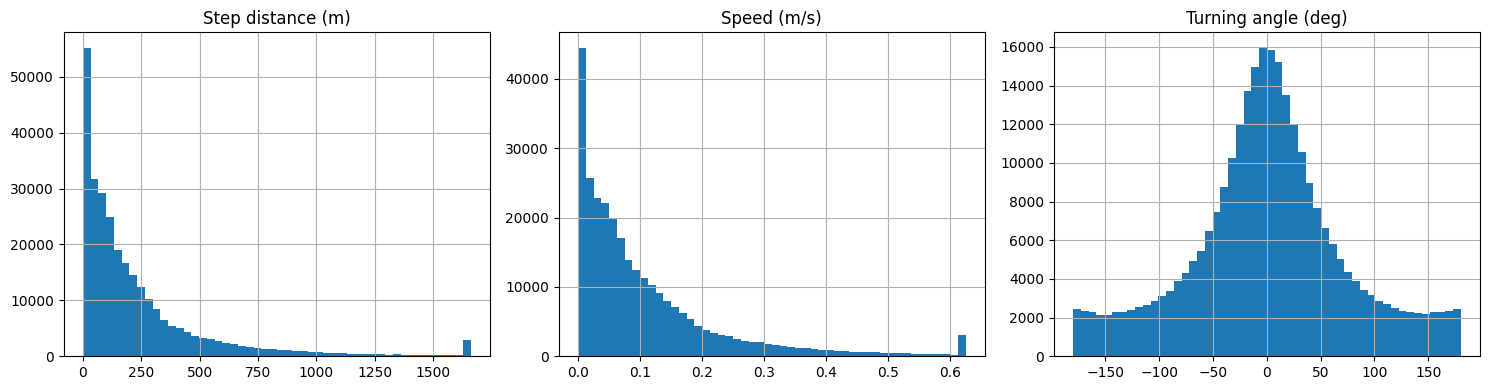

In [14]:
# Visualize movement metrics

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df_moves['step_dist_m'].clip(upper=df_moves['step_dist_m'].quantile(0.99)).hist(bins=50, ax=axes[0])
axes[0].set_title('Step distance (m)')

df_moves['speed_mps'].clip(upper=df_moves['speed_mps'].quantile(0.99)).hist(bins=50, ax=axes[1])
axes[1].set_title('Speed (m/s)')

df_moves['turn_angle_deg'].hist(bins=50, ax=axes[2])
axes[2].set_title('Turning angle (deg)')
plt.tight_layout()
plt.show()

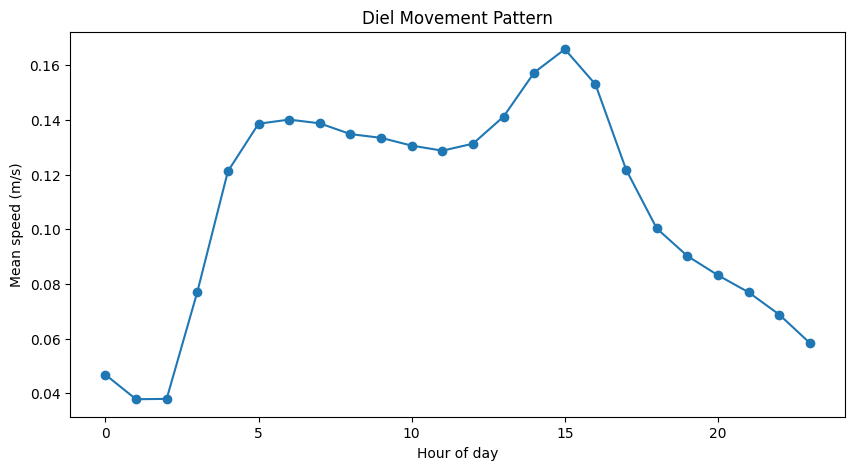

In [15]:
# temperature vs. hour

df_moves['hour'] = df_moves['timestamp'].dt.hour

fig, ax = plt.subplots(figsize=(10, 5))
df_moves.groupby('hour')['speed_mps'].mean().plot(ax=ax, marker='o')
ax.set_ylabel('Mean speed (m/s)')
ax.set_xlabel('Hour of day')
ax.set_title('Diel Movement Pattern')
plt.show()

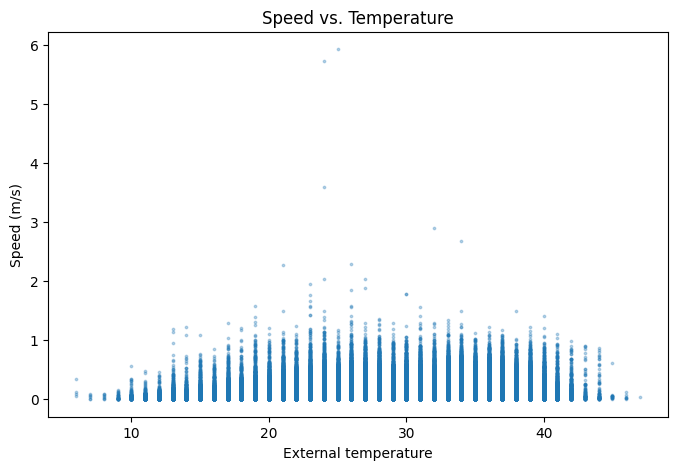

In [16]:
# Temperature vs. movement

plt.figure(figsize=(8,5))
plt.scatter(df_moves['external-temperature'], df_moves['speed_mps'], s=3, alpha=0.3)
plt.xlabel('External temperature')
plt.ylabel('Speed (m/s)')
plt.title('Speed vs. Temperature')
plt.show()

In [17]:
# map the movement interactively

!pip install folium -q
import folium

center_lat = df_moves['location-lat'].mean()
center_lon = df_moves['location-long'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='OpenStreetMap')

individuals = sorted(df_moves['individual-local-identifier'].unique())
cmap = plt.cm.get_cmap('tab20', len(individuals))
color_map = {ind: f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'
             for ind, (r, g, b, a) in zip(individuals, cmap(np.linspace(0, 1, len(individuals))))}

for ind, group in df_moves.groupby('individual-local-identifier'):
    points = list(zip(group['location-lat'], group['location-long']))
    folium.PolyLine(
        points,
        color=color_map[ind],
        weight=2.5,
        opacity=0.7,
        tooltip=ind
    ).add_to(m)
    # mark the starting point of each track
    folium.CircleMarker(
        points[0], radius=4, color=color_map[ind], fill=True, fill_opacity=1,
        popup=f"{ind} - start"
    ).add_to(m)

# simple legend
legend_html = '<div style="position: fixed; bottom: 20px; left: 20px; z-index:9999; background: white; padding: 10px; border:1px solid grey; font-size:12px; max-height:300px; overflow-y:auto;">'
legend_html += '<b>Elephants</b><br>'
for ind, color in color_map.items():
    legend_html += f'<span style="color:{color};">&#9632;</span> {ind}<br>'
legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

m

/tmp/ipykernel_2214/607741061.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(individuals))


In [18]:
!pip install pyarrow -q

In [19]:
# Save the fully processed dataframe - this is the file Notebook 2 will load
output_path = f"{BASE_PATH}/data/processed/df_moves_processed.parquet"
df_moves.to_parquet(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Shape: {df_moves.shape}")
print(f"Columns: {list(df_moves.columns)}")

Saved: /content/drive/MyDrive/wildlife_data/projects/elephants_temperature_knp/data/processed/df_moves_processed.parquet
Shape: (283688, 22)
Columns: ['event-id', 'visible', 'timestamp', 'location-long', 'location-lat', 'external-temperature', 'sensor-type', 'individual-taxon-canonical-name', 'tag-local-identifier', 'individual-local-identifier', 'study-name', 'utm-easting', 'utm-northing', 'utm-zone', 'study-timezone', 'study-local-timestamp', 'step_dist_m', 'step_dt_s', 'bearing_deg', 'speed_mps', 'turn_angle_deg', 'hour']
